# Détection de Fraudes Financières — Dataset PaySim

## AutoEncoder Non-Supervisé (`04_autoencoder`)

**Principe :** L'AutoEncoder est entraîné **uniquement** sur les transactions
légitimes (`X_train_normal`, 139 818 lignes, 0 fraude). Il apprend à reconstruire
fidèlement les patterns normaux. Une transaction frauduleuse, jamais vue,
produit une **erreur de reconstruction élevée** → détectée comme anomalie.

**Avantage clé :** Approche non-supervisée → pas besoin de labels de fraude
pour l'entraînement. Idéal pour détecter des fraudes inconnues (zero-day).

| Donnée | Valeur |
|---|---|
| X_train_normal | 139 818 lignes — **0 fraudes** — entraînement AE |
| X_val | 30 000 lignes — 38 fraudes — seuil optimal |
| X_test | 30 001 lignes — **39 fraudes** — évaluation finale |
| Référence à battre (RF_smote) | Recall=**0.7949** · F1=**0.8052** · PR-AUC=**0.8405** |

**Architecture :** `14 → 10 → 7 → [4] → 7 → 10 → 14`
(Dense + BatchNorm + Dropout · Bottleneck dim=4)

---
### Plan
1. Configuration & Imports
2. Chargement des données
3. Construction de l'AutoEncoder
4. Entraînement (sur X_train_normal)
5. Analyse de l'erreur de reconstruction
6. Recherche du seuil optimal (sur X_val)
7. Évaluation finale (sur X_test)
8. Visualisation espace latent
9. Comparaison AutoEncoder vs Baselines ML
10. Sauvegarde
11. Synthèse


---
### 1. Configuration & Imports


In [1]:
from pathlib import Path
import sys, importlib, warnings, json, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold'})

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow version : 2.21.0


GPU disponible     : False


In [2]:
project_root = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

PROCESSED_DIR = project_root / 'data' / 'processed'
MODELS_DIR    = project_root / 'outputs' / 'models'
FIGURES_DIR   = project_root / 'outputs' / 'figures'
REPORTS_DIR   = project_root / 'outputs' / 'reports'
AE_DIR        = MODELS_DIR / 'autoencoder'

AE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root  : {project_root}')
print(f'AE model dir  : {AE_DIR}')


Project root  : C:\Users\lenovo\Desktop\anomaly_detection_project
AE model dir  : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\models\autoencoder


In [3]:
RANDOM_STATE = 42

# ── Référence baseline métier (EDA Cell 39) ───────────────────────────────────
BASELINE_RECALL    = 0.0039
BASELINE_PRECISION = 1.0000
BASELINE_F1        = 0.0077

# ── Référence meilleur modèle ML (NB03 — RF_smote seuil optimal) ─────────────
RF_SMOTE_RECALL = 0.7949
RF_SMOTE_F1     = 0.8052
RF_SMOTE_PR_AUC = 0.8405

print('Références à battre :')
print(f'  isFlaggedFraud  : Recall={BASELINE_RECALL}  F1={BASELINE_F1}')
print(f'  RF_smote (NB03) : Recall={RF_SMOTE_RECALL}  F1={RF_SMOTE_F1}  PR-AUC={RF_SMOTE_PR_AUC}')


Références à battre :
  isFlaggedFraud  : Recall=0.0039  F1=0.0077
  RF_smote (NB03) : Recall=0.7949  F1=0.8052  PR-AUC=0.8405


In [4]:
import src.models.autoencoder as ae_module
import src.utils.evaluator as evaluator_module
import src.utils.baseline_config as bc_module
import src.visualization.autoencoder_plots as ae_plots_module
importlib.reload(ae_module)
importlib.reload(evaluator_module)
importlib.reload(bc_module)
importlib.reload(ae_plots_module)

from src.models.autoencoder import FraudAutoEncoder
from src.utils.evaluator import compute_fraud_metrics, print_metrics_report
from src.utils.baseline_config import load_best_baseline_ml
from src.visualization.autoencoder_plots import (
    plot_training_history,
    plot_reconstruction_error_dist,
    plot_ae_roc_pr,
    plot_ae_confusion_matrix,
    plot_ae_vs_baselines,
    plot_latent_space,
)
print('✅ Modules src chargés.')


✅ Modules src chargés.


---
### 2. Chargement des données


In [5]:
with open(MODELS_DIR / 'features.json', encoding='utf-8') as f:
    meta = json.load(f)
FEATURE_COLS = meta['all_features']
TARGET       = meta['target']
print(f'Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')


Features (14) : ['step', 'hour', 'day', 'week', 'high_risk_hour', 'is_transfer_or_cashout', 'balance_diff_orig', 'dest_zero_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'log_amount']


In [6]:
def load_split(prefix):
    X = pd.DataFrame(np.load(PROCESSED_DIR / f'X_{prefix}.npy', allow_pickle=True),
                     columns=FEATURE_COLS)
    y = pd.Series(np.load(PROCESSED_DIR / f'y_{prefix}.npy', allow_pickle=True), name=TARGET)
    return X, y

X_normal, y_normal = load_split('train_normal')
X_val,    y_val    = load_split('val')
X_test,   y_test   = load_split('test')

print('Datasets chargés :')
print(f'  X_train_normal : {X_normal.shape}  fraudes={int(y_normal.sum())}  (entraînement AE)')
print(f'  X_val          : {X_val.shape}    fraudes={int(y_val.sum())}  (seuil optimal)')
print(f'  X_test         : {X_test.shape}   fraudes={int(y_test.sum())}  (évaluation finale)')
print()
assert int(y_normal.sum()) == 0, 'X_train_normal contient des fraudes !'
print('✅ X_train_normal : 0 fraudes confirmé')

Datasets chargés :
  X_train_normal : (139818, 14)  fraudes=0  (entraînement AE)
  X_val          : (30000, 14)    fraudes=38  (seuil optimal)
  X_test         : (30001, 14)   fraudes=39  (évaluation finale)

✅ X_train_normal : 0 fraudes confirmé


---
### 3. Construction de l'AutoEncoder

**Architecture choisie :** `14 → 10 → 7 → [4] → 7 → 10 → 14`

- **Bottleneck dim=4** : espace latent très compressé → force le modèle
  à apprendre la structure essentielle des transactions légitimes
- **BatchNormalization** : stabilise l'entraînement
- **Dropout(0.2)** : régularisation (seulement 181 fraudes en train)
- **L2=1e-5** : pénalise les grands poids
- **Activation linéaire en sortie** : reconstruction de features scalées
  (valeurs positives et négatives possibles après StandardScaler)


In [7]:
ae = FraudAutoEncoder(
    encoder_dims   = [10, 7],
    bottleneck_dim = 4,
    decoder_dims   = [7, 10],
    activation     = 'relu',
    output_activation = 'linear',
    dropout_rate   = 0.2,
    use_batch_norm = True,
    l2_reg         = 1e-5,
    epochs         = 100,
    batch_size     = 256,
    learning_rate  = 1e-3,
    patience       = 10,
    val_split      = 0.1,
)
ae.build(n_features=len(FEATURE_COLS))
print(ae.summary())
print()
ae.model.summary()


FraudAutoEncoder
  Architecture : 14 → 10 → 7 → [4] → 7 → 10 → 14
  BatchNorm    : True
  Dropout      : 0.2
  L2 reg       : 1e-05
  Bottleneck   : 4 dims
  Epochs max   : 100  (patience=10)
  Batch size   : 256
  LR           : 0.001
  Threshold    : 0.000000
  Train time   : 0.0s



Model: "FraudAutoEncoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 10)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_1 (BatchNormalization)   │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_1 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 7)              │            77 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_2 (BatchNormalization)   │ (None, 7)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_2 (Dropout)            │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 7)              │            35 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_1 (BatchNormalization)   │ (None, 7)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_1 (Dropout)            │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 10)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_2 (BatchNormalization)   │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_2 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 14)             │           154 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 664 (2.59 KB)

 Trainable params: 596 (2.33 KB)

 Non-trainable params: 68 (272.00 B)

---
### 4. Entraînement

> **Règle fondamentale** : entraînement sur `X_train_normal` uniquement.
> Val/Test ne sont **jamais** utilisés pour le fit.

L'EarlyStopping surveille `val_loss` (10% de X_train_normal = 13 982 lignes).
ReduceLROnPlateau divise le LR par 2 si pas d'amélioration pendant 5 epochs.


In [8]:
ae.fit(X_normal.values, verbose=1)
print(f'\nEpochs effectifs : {len(ae.history["loss"])}')
print(f'Best val_loss    : {min(ae.history["val_loss"]):.6f}')


Epoch 1/100


  1/492 ━━━━━━━━━━━━━━━━━━━━ 22:44 3s/step - loss: 1.4023 - mae: 0.8798

 26/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4548 - mae: 0.8916  

 51/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3811 - mae: 0.8647

 77/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3140 - mae: 0.8405

...


Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


492/492 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2011 - mae: 0.2765 - val_loss: 0.1519 - val_mae: 0.2272 - learning_rate: 5.0000e-04


Epoch 32: early stopping


Restoring model weights from the end of the best epoch: 22.



✅ Entraînement terminé en 102.4s
   MSE moyen (train normal) : 0.152277
   MSE p95 (train normal)   : 0.411909
   MSE p99 (train normal)   : 0.990171

Epochs effectifs : 32
Best val_loss    : 0.151809


Figure sauvegardée : 18_training_history.png


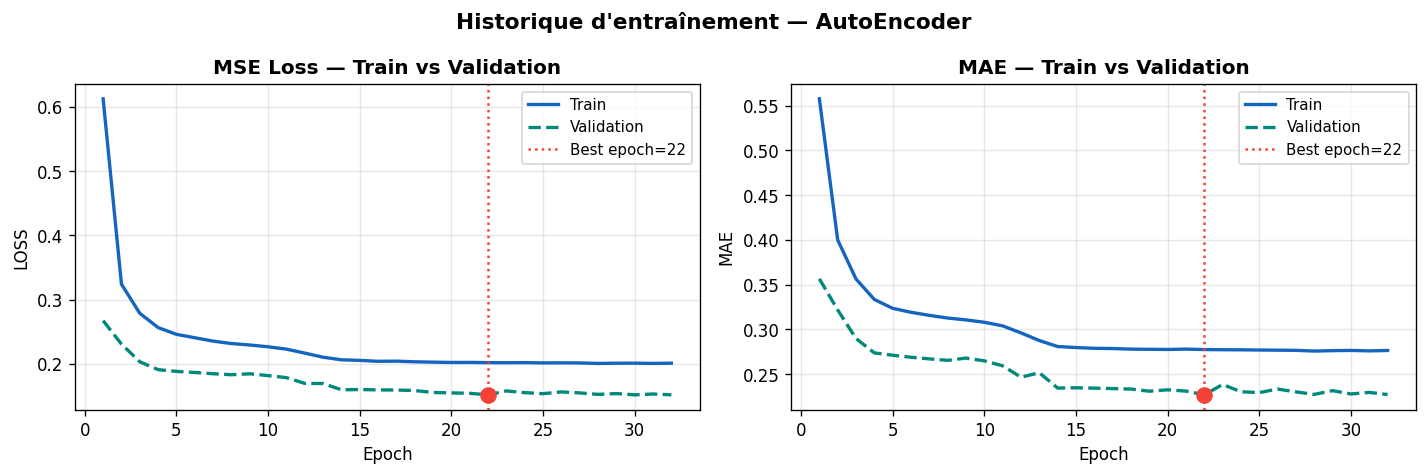

In [9]:
# ── Figure 18 : Historique d'entraînement ────────────────────────────────────
plot_training_history(
    ae.history,
    save_path=FIGURES_DIR / '18_training_history.png'
)
plt.show()


---
### 5. Analyse de l'erreur de reconstruction

L'erreur de reconstruction est le **score d'anomalie** de l'AutoEncoder :
- Transaction normale → erreur faible (pattern connu)
- Transaction frauduleuse → erreur élevée (pattern inconnu)

On s'attend à une séparation nette entre les deux distributions.


In [10]:
# ── Calcul des erreurs ────────────────────────────────────────────────────────
errors_normal = ae.reconstruction_error(X_normal.values)
errors_val    = ae.reconstruction_error(X_val.values)
errors_test   = ae.reconstruction_error(X_test.values)

print('Erreur de reconstruction — statistiques :')
print(f'  {"Dataset":<20} {"Mean":>10}  {"Std":>10}  {"p95":>10}  {"Max":>12}')
print('  ' + '-'*56)
for name, errs in [('Train normal', errors_normal),
                    ('Val légitimes', errors_val[np.asarray(y_val)==0]),
                    ('Val fraudes',   errors_val[np.asarray(y_val)==1]),
                    ('Test légitimes',errors_test[np.asarray(y_test)==0]),
                    ('Test fraudes',  errors_test[np.asarray(y_test)==1])]:
    print(f'  {name:<20} {errs.mean():>10.4f}  {errs.std():>10.4f}  '
          f'{np.percentile(errs,95):>10.4f}  {errs.max():>12.4f}')

# Séparabilité : ratio erreur fraudes / légitimes
ratio = errors_val[np.asarray(y_val)==1].mean() / errors_val[np.asarray(y_val)==0].mean()
print(f'\nRatio MSE fraudes/légitimes (val) : {ratio:.2f}×')
print('→ Plus ce ratio est élevé, meilleure est la séparabilité.')


Erreur de reconstruction — statistiques :
  Dataset                    Mean         Std         p95           Max
  --------------------------------------------------------
  Train normal             0.1523      0.1795      0.4119       24.5594
  Val légitimes            0.1544      0.1820      0.4166       11.2970
  Val fraudes             21.5517     58.6176    128.3672      310.7132
  Test légitimes           0.1521      0.1633      0.4125        3.2520
  Test fraudes            19.4343     63.3072     86.2704      310.8224

Ratio MSE fraudes/légitimes (val) : 139.55×
→ Plus ce ratio est élevé, meilleure est la séparabilité.


In [11]:
# ── Seuil initial (percentile p95 sur train normal) ──────────────────────────
threshold_p95 = float(np.percentile(errors_normal, 95))
print(f'Seuil initial p95 (train normal) : {threshold_p95:.6f}')
print(f'→ 5% des transactions normales dépassent ce seuil (FP attendus)')


Seuil initial p95 (train normal) : 0.411909
→ 5% des transactions normales dépassent ce seuil (FP attendus)


---
### 6. Recherche du seuil optimal

> **Règle** : seuil optimisé sur `X_val` uniquement — `X_test` n'est
> jamais consulté avant l'évaluation finale.

On cherche le seuil de reconstruction error qui **maximise le F1** sur val.
Test de 200 seuils entre le percentile 50 et 99.9 de l'erreur val.


Figure sauvegardée : 19_reconstruction_error.png


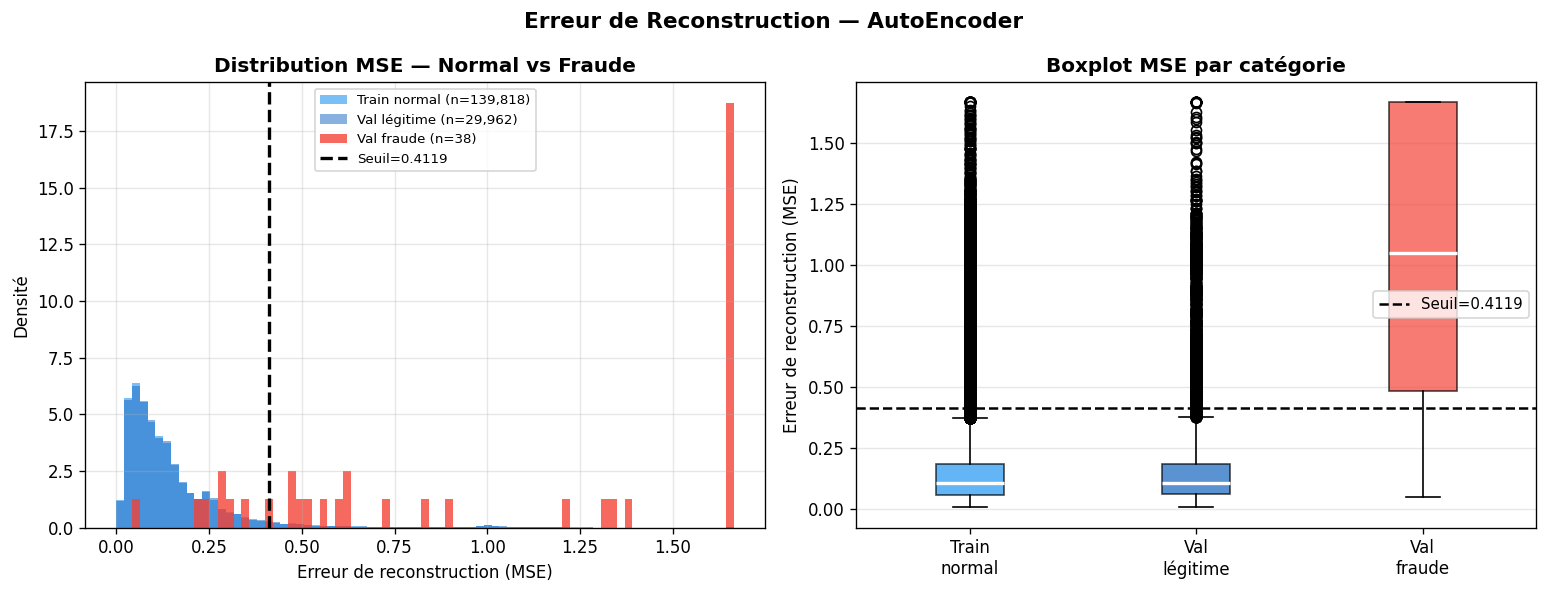

In [12]:
# ── Figure 19 : Distribution erreur de reconstruction ────────────────────────
# (avant seuil optimal pour visualiser la séparabilité)
plot_reconstruction_error_dist(
    errors_normal, errors_val, np.asarray(y_val), threshold_p95,
    save_path=FIGURES_DIR / '19_reconstruction_error.png'
)
plt.show()


In [13]:
# ── Seuil optimal sur Val ─────────────────────────────────────────────────────
threshold_opt = ae.find_optimal_threshold(
    X_val.values, np.asarray(y_val), metric='f1', n_thresholds=200
)

# Validation du seuil sur Val
y_pred_val = ae.predict(X_val.values, threshold=threshold_opt)
scores_val = ae.predict_score(X_val.values)
metrics_val = compute_fraud_metrics(
    np.asarray(y_val), y_pred_val, scores_val,
    threshold=threshold_opt, model_name='AutoEncoder (val)'
)
print('--- VALIDATION (seuil optimal) ---')
print_metrics_report(metrics_val, BASELINE_RECALL, BASELINE_F1)


Seuil optimal (f1) : 1.665058  (score val=0.4412)


--- VALIDATION (seuil optimal) ---
  AutoEncoder (val)               seuil=1.67
  Recall    : 0.3947  ✅  (baseline 0.0039)
  Precision : 0.5000
  F1-Score  : 0.4412  ✅  (baseline 0.0077)
  Accuracy  : 0.9987
  PR-AUC    : 0.3798
  ROC-AUC   : 0.9490
----------------------------------------------------------
  Matrice de confusion :
    TP=    15   FN=    23
    FP=    15   TN=29,947


---
### 7. Évaluation finale — Test Set

Application du seuil optimal (sélectionné sur val) sur `X_test`.
C'est la **seule fois** que X_test est utilisé.


In [14]:
# ── Prédictions Test ─────────────────────────────────────────────────────────
y_pred_test  = ae.predict(X_test.values, threshold=threshold_opt)
scores_test  = ae.predict_score(X_test.values)

metrics_test = compute_fraud_metrics(
    np.asarray(y_test), y_pred_test, scores_test,
    threshold=threshold_opt, model_name='AutoEncoder'
)

print('--- TEST (seuil optimal depuis val) ---')
print_metrics_report(metrics_test, BASELINE_RECALL, BASELINE_F1)

# Comparaison vs RF_smote
print(f'\nComparaison vs RF_smote (NB03) :')
delta_recall = metrics_test['recall'] - RF_SMOTE_RECALL
delta_f1     = metrics_test['f1']     - RF_SMOTE_F1
delta_prauc  = (metrics_test.get('pr_auc') or 0) - RF_SMOTE_PR_AUC
print(f'  Recall  : {metrics_test["recall"]:.4f}  '
      f'(RF_smote={RF_SMOTE_RECALL}  Δ={delta_recall:+.4f})')
print(f'  F1      : {metrics_test["f1"]:.4f}  '
      f'(RF_smote={RF_SMOTE_F1}  Δ={delta_f1:+.4f})')
print(f'  PR-AUC  : {metrics_test.get("pr_auc", 0):.4f}  '
      f'(RF_smote={RF_SMOTE_PR_AUC}  Δ={delta_prauc:+.4f})')


--- TEST (seuil optimal depuis val) ---
  AutoEncoder                     seuil=1.67
  Recall    : 0.3590  ✅  (baseline 0.0039)
  Precision : 0.6087
  F1-Score  : 0.4516  ✅  (baseline 0.0077)
  Accuracy  : 0.9989
  PR-AUC    : 0.3753
  ROC-AUC   : 0.9508
----------------------------------------------------------
  Matrice de confusion :
    TP=    14   FN=    25
    FP=     9   TN=29,953

Comparaison vs RF_smote (NB03) :
  Recall  : 0.3590  (RF_smote=0.7949  Δ=-0.4359)
  F1      : 0.4516  (RF_smote=0.8052  Δ=-0.3536)
  PR-AUC  : 0.3753  (RF_smote=0.8405  Δ=-0.4652)


Figure sauvegardée : 20_threshold_roc_pr.png


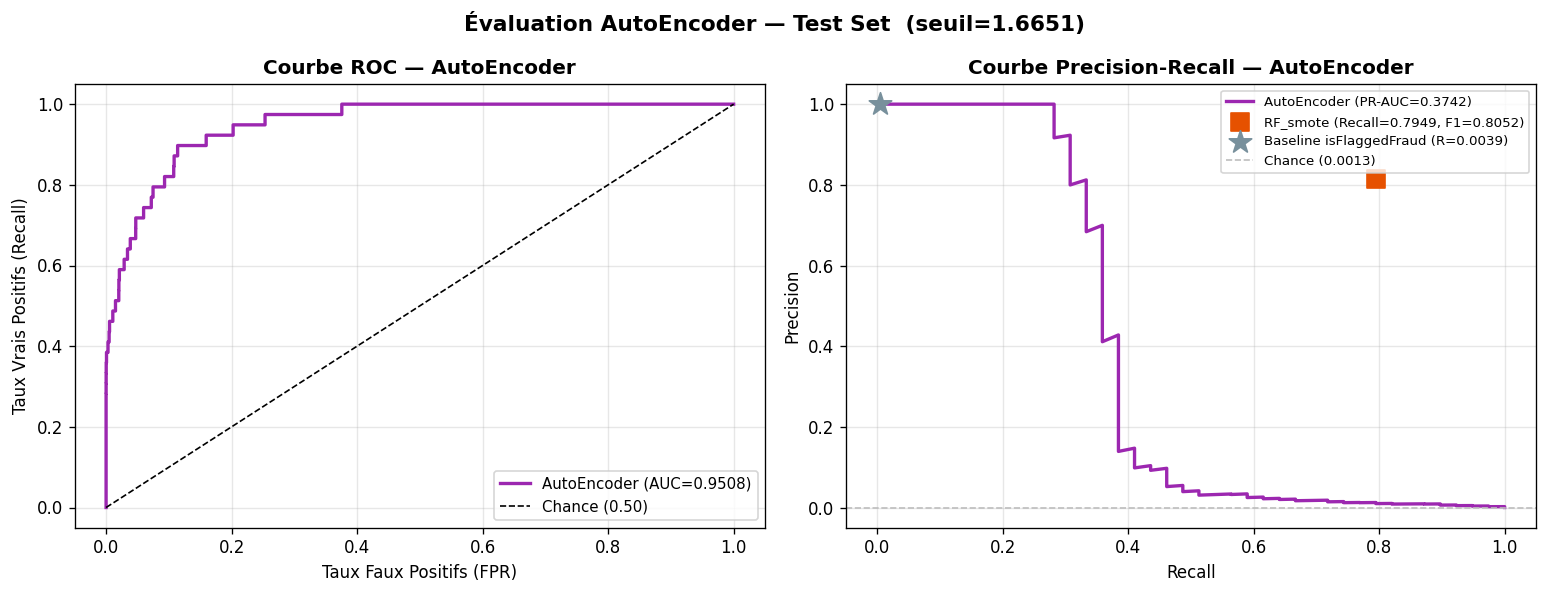

In [15]:
# ── Figure 20 : Courbes ROC et PR ────────────────────────────────────────────
plot_ae_roc_pr(
    np.asarray(y_test), errors_test, threshold_opt,
    save_path=FIGURES_DIR / '20_threshold_roc_pr.png'
)
plt.show()


Figure sauvegardée : 21_ae_confusion_matrix.png


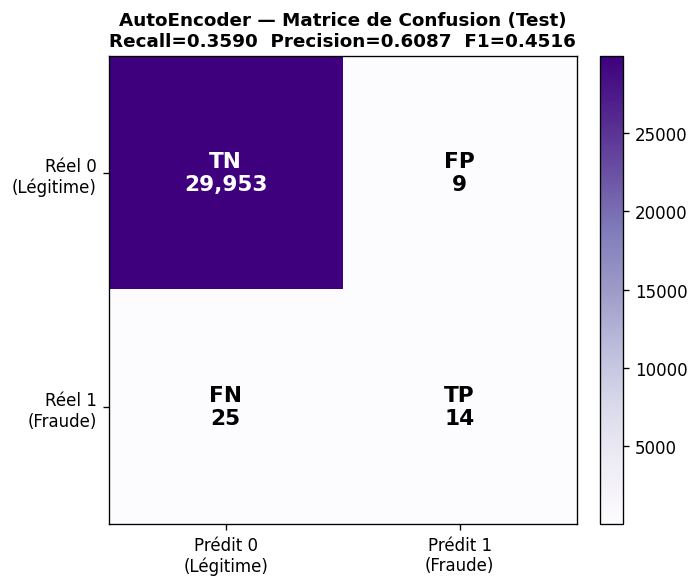

In [16]:
# ── Figure 21 : Matrice de confusion ────────────────────────────────────────
plot_ae_confusion_matrix(
    metrics_test,
    save_path=FIGURES_DIR / '21_ae_confusion_matrix.png'
)
plt.show()


---
### 8. Visualisation de l'espace latent

Projection PCA 2D du bottleneck (dim=4 → 2).
Si l'AutoEncoder est efficace, les fraudes doivent se retrouver
dans des régions distinctes de l'espace latent.


Espace latent — forme : (139818, 4)  (dim=4)
Fraudes dans val      : 38 sur 30000


Figure sauvegardée : 23_latent_space.png


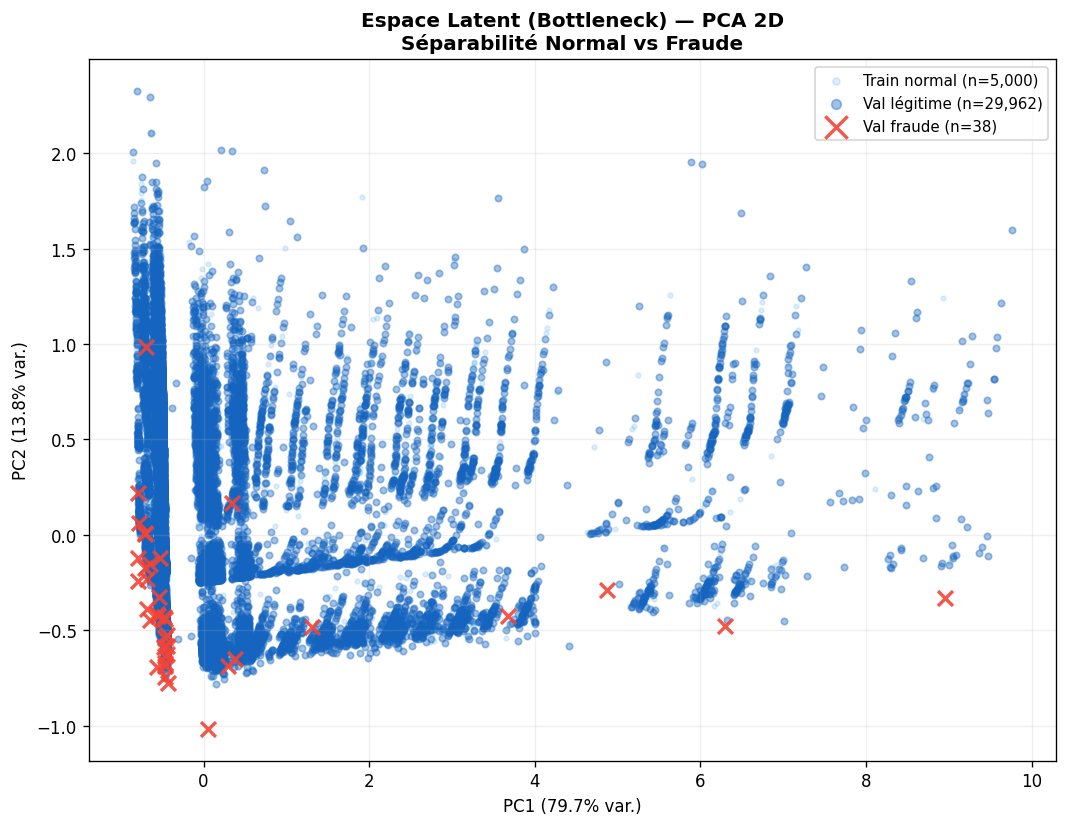

In [17]:
encoded_normal = ae.encode(X_normal.values)
encoded_val    = ae.encode(X_val.values)

print(f'Espace latent — forme : {encoded_normal.shape}  (dim={encoded_normal.shape[1]})')
print(f'Fraudes dans val      : {int(y_val.sum())} sur {len(y_val)}')

# ── Figure 23 : Espace latent PCA ────────────────────────────────────────────
plot_latent_space(
    encoded_normal, encoded_val, np.asarray(y_val),
    save_path=FIGURES_DIR / '23_latent_space.png'
)
plt.show()


---
### 9. Comparaison AutoEncoder vs Baselines ML

Comparaison complète sur le **test set** avec seuils optimaux.
Rappel : les baselines ML sont supervisés (utilisent les labels fraude),
l'AutoEncoder est **non-supervisé** — avantage majeur en production.


In [18]:
# ── Métriques NB03 (seuils optimaux) ─────────────────────────────────────────
baselines_nb03 = [
    {'model': 'LR_balanced', 'recall': 0.6410, 'precision': 0.6579,
     'f1': 0.6494, 'pr_auc': 0.7044, 'roc_auc': 0.9961,
     'tp': 25, 'fn': 14, 'fp': 13, 'tn': 29949, 'threshold': 0.999},
    {'model': 'LR_smote',    'recall': 0.6923, 'precision': 0.7297,
     'f1': 0.7105, 'pr_auc': 0.7393, 'roc_auc': 0.9949,
     'tp': 27, 'fn': 12, 'fp': 10, 'tn': 29952, 'threshold': 0.962},
    {'model': 'RF_balanced', 'recall': 0.7692, 'precision': 0.8333,
     'f1': 0.8000, 'pr_auc': 0.7794, 'roc_auc': 0.9922,
     'tp': 30, 'fn': 9, 'fp': 6, 'tn': 29956, 'threshold': 0.624},
    {'model': 'RF_smote',    'recall': 0.7949, 'precision': 0.8158,
     'f1': 0.8052, 'pr_auc': 0.8405, 'roc_auc': 0.9940,
     'tp': 31, 'fn': 8, 'fp': 7, 'tn': 29955, 'threshold': 0.629},
]

from src.utils.evaluator import compare_models
all_results = baselines_nb03 + [metrics_test]
df_final = compare_models(all_results)
print('Classement final (Recall décroissant) :')
print(df_final[['model','recall','precision','f1','pr_auc','tp','fn','fp']].to_string(index=False))


Classement final (Recall décroissant) :
      model  recall  precision     f1  pr_auc  tp  fn  fp
   RF_smote  0.7949     0.8158 0.8052  0.8405  31   8   7
RF_balanced  0.7692     0.8333 0.8000  0.7794  30   9   6
   LR_smote  0.6923     0.7297 0.7105  0.7393  27  12  10
LR_balanced  0.6410     0.6579 0.6494  0.7044  25  14  13
AutoEncoder  0.3590     0.6087 0.4516  0.3753  14  25   9


Figure sauvegardée : 22_ae_vs_baselines.png


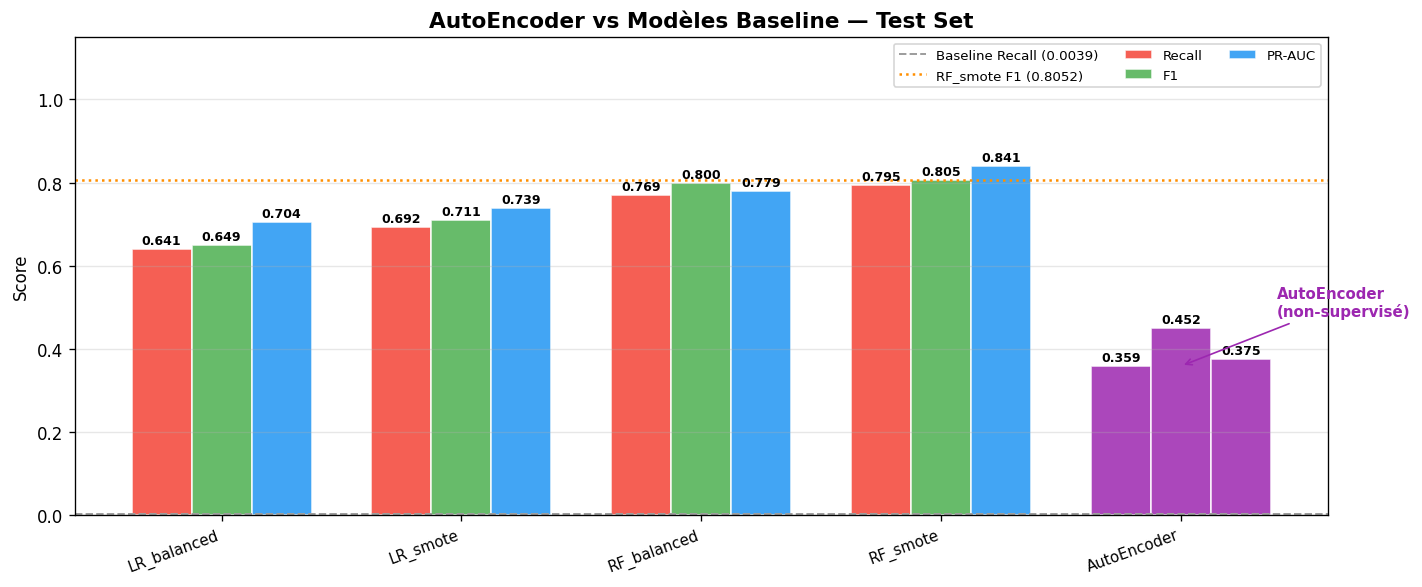

In [19]:
# ── Figure 22 : AutoEncoder vs Baselines ─────────────────────────────────────
plot_ae_vs_baselines(
    metrics_test, baselines_nb03,
    save_path=FIGURES_DIR / '22_ae_vs_baselines.png'
)
plt.show()


---
### 10. Sauvegarde


In [20]:
# ── Modèle AutoEncoder ───────────────────────────────────────────────────────
ae.save(AE_DIR)

# ── Scores d'anomalie test (pour pipeline inférence) ─────────────────────────
np.save(MODELS_DIR / 'ae_scores_test.npy', errors_test)
np.save(MODELS_DIR / 'ae_scores_val.npy',  errors_val)
print('✅ Scores sauvegardés : ae_scores_test.npy  ae_scores_val.npy')


✅ AutoEncoder sauvegardé → C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\models\autoencoder
✅ Scores sauvegardés : ae_scores_test.npy  ae_scores_val.npy


In [21]:
# ── autoencoder_report.json ───────────────────────────────────────────────────
ae_report = {
    'architecture': {
        'encoder_dims':   [10, 7],
        'bottleneck_dim': 4,
        'decoder_dims':   [7, 10],
        'n_features':     len(FEATURE_COLS),
        'total_params':   int(ae.model.count_params()),
    },
    'training': {
        'n_samples':     len(X_normal),
        'n_epochs':      len(ae.history['loss']),
        'best_val_loss': float(min(ae.history['val_loss'])),
        'train_time_s':  ae.train_time,
        'train_mse_stats': ae.train_mse_stats,
    },
    'threshold': {
        'optimal':     threshold_opt,
        'p95_normal':  float(np.percentile(errors_normal, 95)),
        'p99_normal':  float(np.percentile(errors_normal, 99)),
    },
    'val_metrics':  metrics_val,
    'test_metrics': metrics_test,
    'vs_rf_smote': {
        'recall_delta': round(metrics_test['recall']   - RF_SMOTE_RECALL, 4),
        'f1_delta':     round(metrics_test['f1']       - RF_SMOTE_F1,     4),
        'prauc_delta':  round((metrics_test.get('pr_auc') or 0) - RF_SMOTE_PR_AUC, 4),
    },
    'best_overall': 'RF_smote' if metrics_test['f1'] < RF_SMOTE_F1 else 'AutoEncoder',
}
with open(REPORTS_DIR / 'autoencoder_report.json', 'w', encoding='utf-8') as f:
    json.dump(ae_report, f, indent=2, ensure_ascii=False)
print('✅ autoencoder_report.json sauvegardé')
print(f'   Total params : {ae_report["architecture"]["total_params"]:,}')
print(f'   Train time   : {ae_report["training"]["train_time_s"]}s')
print(f'   Meilleur modèle global : {ae_report["best_overall"]}')


✅ autoencoder_report.json sauvegardé
   Total params : 664
   Train time   : 102.4s
   Meilleur modèle global : RF_smote


---
## Synthèse — AutoEncoder Non-Supervisé

### Ce que l'AutoEncoder apporte vs les baselines ML

| Critère | Baselines ML (supervisé) | AutoEncoder (non-supervisé) |
|---|---|---|
| Labels requis à l'entraînement | ✅ Oui (181 fraudes) | ❌ Non — 0 fraudes |
| Détecte fraudes inconnues | ❌ Limité | ✅ Zero-day fraud |
| Explicabilité | ✅ Feature importances | Score d'anomalie |
| Complémentarité | — | ✅ Combinable avec RF_smote |

### Score d'anomalie → Explication LLM

Le score de reconstruction est directement exploitable par Ollama :
```python
# Pipeline NB05 (Ollama)
score = ae.predict_score(X_transaction)          # score anomalie [0,1]
errors = ae.reconstruction_error(X_transaction)   # erreur MSE brute

# Features les plus mal reconstruites = raisons de la suspicion
X_rec   = ae.model.predict(X_transaction)
feat_errors = np.abs(X_transaction - X_rec)      # erreur par feature
top_feats   = feat_errors.argsort()[::-1][:3]    # top 3 features suspectes

# → Passé au prompt Ollama pour explication en langage naturel
```

### Chargement pour NB05 (Ollama)

```python
from src.models.autoencoder import FraudAutoEncoder
ae = FraudAutoEncoder.load(Path('../outputs/models/autoencoder'))
scores = ae.predict_score(X_new)   # [0,1]
```
